# W06

In [6]:
import numpy as np
from matplotlib import pyplot as plt
import sklearn
from sklearn.mixture import GaussianMixture

In [7]:
data = np.load('/Users/lorenzaimpicicche/Desktop/astrostatistics_bicocca_2025/working/formationchannels.npy')
data #black hole mass

array([[17.12172682],
       [ 5.94121793],
       [ 6.35914124],
       ...,
       [34.34170191],
       [30.27018478],
       [25.93264098]])

(array([0.00063165, 0.        , 0.00063165, 0.00063165, 0.00063165,
        0.        , 0.00126329, 0.00189494, 0.00126329, 0.00063165,
        0.00252658, 0.00063165, 0.00189494, 0.00442152, 0.00378987,
        0.0069481 , 0.00252658, 0.0069481 , 0.00568481, 0.00947468,
        0.00821139, 0.00568481, 0.0069481 , 0.01200126, 0.01200126,
        0.0069481 , 0.01010633, 0.01073797, 0.01200126, 0.00757974,
        0.00884304, 0.00884304, 0.00568481, 0.00947468, 0.00821139,
        0.00252658, 0.00757974, 0.00631645, 0.00189494, 0.00315823,
        0.00505316, 0.00884304, 0.01452784, 0.02526582, 0.04547847,
        0.07390251, 0.09158858, 0.08148226, 0.06569112, 0.03221392,
        0.02400253, 0.01642278, 0.03031898, 0.0277924 , 0.02968733,
        0.02968733, 0.03221392, 0.04611011, 0.03726708, 0.05053163,
        0.04358353, 0.04737341, 0.04926834, 0.05368986, 0.05179492,
        0.0555848 , 0.0543215 , 0.05305821, 0.05053163, 0.04484682,
        0.05495315, 0.03663543, 0.03600379, 0.04

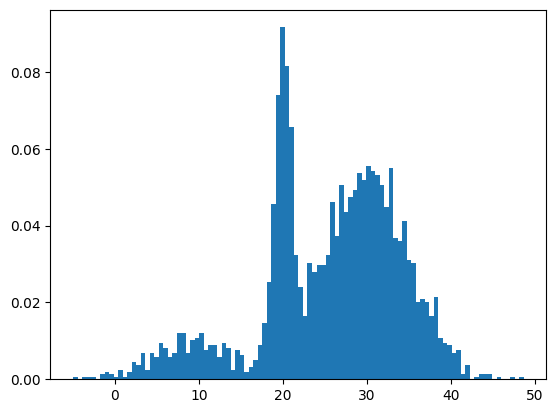

In [8]:
plt.hist(data, bins=100, density=True)

In [9]:
gm = GaussianMixture(n_components=3, random_state=0).fit(data)

In [18]:
x = np.linspace(0, 50, 1000).reshape(-1, 1) 

gm_log = gm.score(data) #score:just a point, score_samples: for each point
print(gm_log)

gm_pdf = np.exp(gm.score_samples(x)) # exp(log(p(x))))

-3.4012388398828977


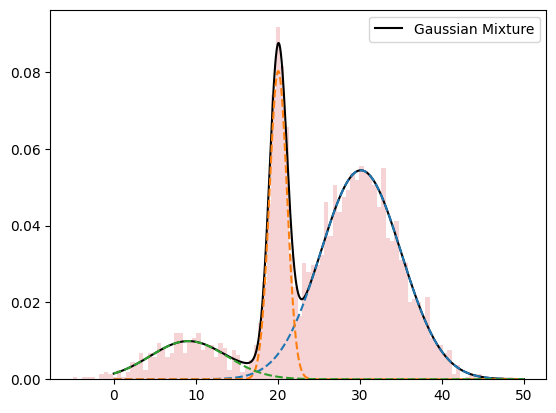

In [17]:
plt.plot(x, gm_pdf, color='black',label='Gaussian Mixture')

for m, cov, w in zip(gm.means_.flatten(), gm.covariances_.flatten(), gm.weights_): #flatten=1D array
    gauss_i = w * np.exp(-0.5*((x-m)**2)/cov)/np.sqrt(2*np.pi*cov)
    plt.plot(x, gauss_i, linestyle='--')
    
plt.hist(data, bins=100, density=True, alpha=0.2) 
plt.legend()

### N vs AIC

Text(0, 0.5, 'AIC')

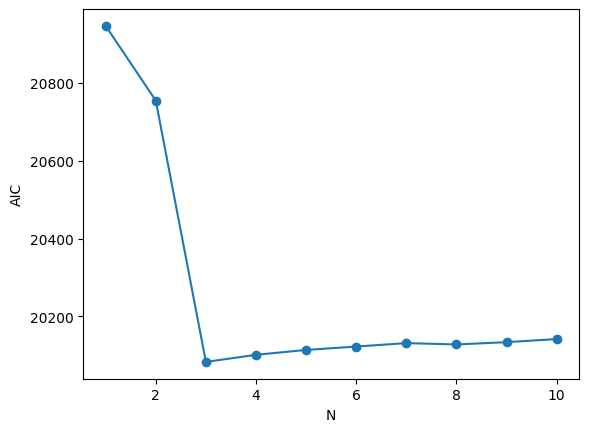

In [21]:
aic=[]
models=[]

for i in range(1, 11):
    gmm=GaussianMixture(n_components=i, random_state=0)
    gmm.fit(data)
    aic_i=gmm.aic(data)
    aic.append(aic_i)
    models.append(gmm)

# Plot AIC vs N
plt.plot(range(1, 11), aic, marker='o')
plt.xlabel('N')
plt.ylabel('AIC')

In [25]:
best=np.argmin(aic)+1
best

3

In [27]:
model_b=models[np.argmin(aic)]
model_b

GaussianMixture(n_components=3, random_state=0)